Goal:
Use LIME to explain why a model made a particular prediction, by fitting a local surrogate model around that instance. You’ll:

Train a pipeline (Titanic, classification),

Wrap it with LIME (lime_tabular.LimeTabularExplainer),

Generate explanations for individual passengers,

Visualize feature contributions, and

Compare explanations across different passengers.

In [2]:
# pip install lime scikit-learn pandas numpy seaborn matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import lime
import lime.lime_tabular
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [3]:
df = sns.load_dataset('titanic').drop(columns=['alive'])
target = 'survived'
features = ['pclass','sex','age','sibsp','parch','fare','embarked','class','who','alone']
df = df[features+[target]].copy()
df[target] = df[target].astype(int)

X = df[features]; y = df[target]

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

clf = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1)
pipe = Pipeline([('prep', prep), ('rf', clf)])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
pipe.fit(X_tr, y_tr)

proba = pipe.predict_proba(X_te)[:,1]
print("Hold-out Acc:", round(accuracy_score(y_te, pipe.predict(X_te)),3))
print("Hold-out ROC-AUC:", round(roc_auc_score(y_te, proba),3))

Hold-out Acc: 0.827
Hold-out ROC-AUC: 0.834


2) Extract transformed data & feature names
LIME needs raw numpy arrays and interpretable feature names.

In [4]:
Xt_tr = pipe.named_steps['prep'].transform(X_tr)
Xt_te = pipe.named_steps['prep'].transform(X_te)

oh = pipe.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
feat_names = list(num_cols) + oh.get_feature_names_out(cat_cols).tolist()
len(feat_names), Xt_te.shape

(18, (179, 18))

3) Create a LIME explainer

In [5]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = Xt_tr,
    feature_names = feat_names,
    class_names = ['died','survived'],
    mode = 'classification',
    discretize_continuous = True,     # bins continuous vars for interpretability
    random_state = 0
)

4) Explain a single prediction
Pick one passenger from the test set:

In [8]:
i = 5
row_raw = X_te.iloc[[i]]               # original passenger features
row_trans = Xt_te[i]               # transformed features
# No need to wrap row_raw in [] anymore, it is already a 2D DataFrame
pred_proba = pipe.predict_proba(row_raw)[0][1]

print("Passenger idx:", i, "| predicted P(survive) =", round(pred_proba,3))
row_raw

Passenger idx: 5 | predicted P(survive) = 0.295


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone
559,3,female,36.0,1,0,17.4,S,Third,woman,False


Generate explanation:

[('who_man <= 0.00', 0.2121559641627294), ('0.00 < sex_female <= 1.00', 0.1154470605487189), ('sex_male <= 0.00', 0.09897499236560008), ('0.00 < who_woman <= 1.00', 0.06932961419349953), ('-0.37 < pclass <= 0.83', -0.06216674335469486), ('0.00 < class_Third <= 1.00', -0.058340180413499025), ('who_child <= 0.00', -0.05551413797562862), ('class_First <= 0.00', -0.05319252957131269)]


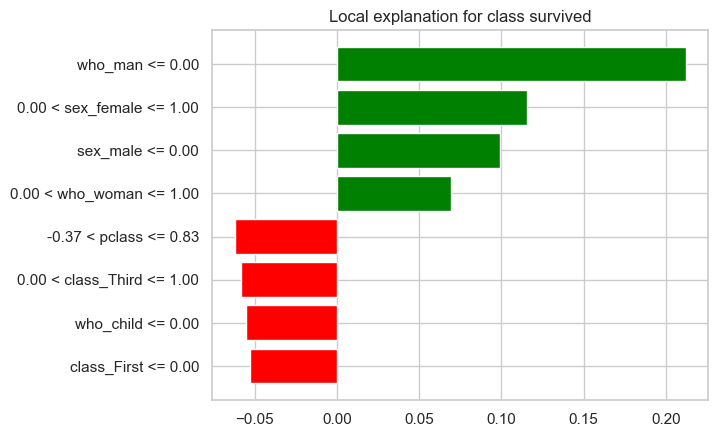

In [10]:
# ... previous code ...
exp = explainer.explain_instance(
    data_row=row_trans,
    predict_fn=pipe.named_steps['rf'].predict_proba,
    num_features=8
)

# 1. Comment out the notebook display line causing the error
# exp.show_in_notebook(show_table=True)

# 2. Save to HTML instead (this is often more reliable)
exp.save_to_file('lime_explanation_passenger5.html')

# 3. Alternatively, print the explanation as a simple list to verify content
print(exp.as_list())

# 4. If you want a static plot inside the notebook (no JS required)
%matplotlib inline
fig = exp.as_pyplot_figure()


5) Visualize explanation (bar chart style)

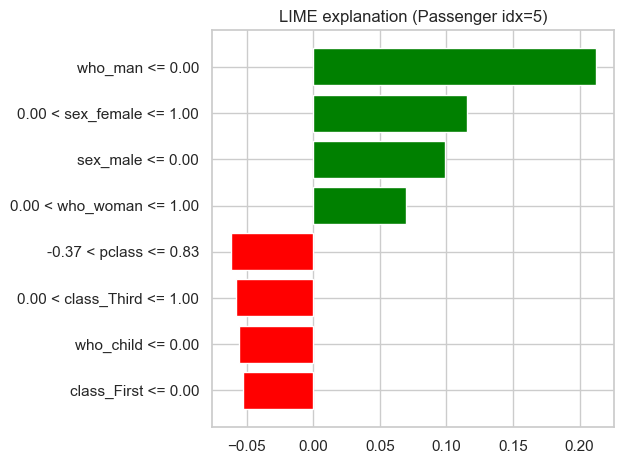

In [11]:
fig = exp.as_pyplot_figure()
plt.title("LIME explanation (Passenger idx=5)")
plt.tight_layout(); plt.show()

Interpretation:
Each bar shows how much that feature pushed the prediction toward survival (green) or death (red). LIME builds a local linear model around this passenger to approximate the black-box RF.

6) Compare multiple passengers